In [3]:
%pip install uproot

In [5]:
%pip install awkward_pandas

**NEW CLASSIFICATION**

In [13]:
# ==========================================================
# Three-Gamma CNN Regression
# Predict:
#   - Annihilation X
#   - Annihilation Y
#   - Annihilation Z
#   - Total deposited energy
# ==========================================================

import os
import numpy as np
import pandas as pd
import uproot

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    BatchNormalization,
    MaxPooling2D,
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [15]:
# ==========================================================
# Load ROOT file
# ==========================================================

ROOT_FILE = "new3merged.root"

file = uproot.open(ROOT_FILE)

print(file.keys())


['TwoG_NCS;1', 'TwoG_PhantomSCS;1', 'TwoG_ScannerSCS;1', 'TwoG_PhantomSCS_ScannerSCS;1', 'TwoG_PhantomDCS;1', 'TwoG_ScannerDCS;1', 'TwoG_PhantomSCS_ScannerDCS;1', 'TwoG_PhantomDCS_ScannerSCS;1', 'TwoG_PhantomDCS_ScannerDCS;1', 'TwoG_MCS;1', 'TwoG_Excluded;1', 'ThreeG_NCS;1', 'ThreeG_ScannerSCS;1', 'ThreeG_ScannerDCS;1', 'ThreeG_ScannerTCS;1', 'ThreeG_MCS;1', 'ThreeG_Excluded;1', 'Run;1']


In [16]:
branches = [

    "RunID",
    "EventID",

    "GammaIndex",

    "X_mm",
    "Y_mm",
    "Z_mm",

    "EnergyDeposit_keV",
    "PreEnergy_keV",
    "PostEnergy_keV",

    "AnnihilX_mm",
    "AnnihilY_mm",
    "AnnihilZ_mm"

]

tree = file["ThreeG_NCS"]
df = tree.arrays(branches, library="pd")

print(df.head())

              RunID  EventID  GammaIndex       X_mm       Y_mm       Z_mm  \
0  slurm_35882963_1        0           0  42.213463 -29.997831 -44.219231   
1  slurm_35882963_1        0           1 -39.140385  43.925343  13.321461   
2  slurm_35882963_1        0           2  24.441950 -43.796162   5.251225   
3  slurm_35882963_1       14           0  25.520941  44.251762   1.901691   
4  slurm_35882963_1       14           1  50.743858  24.093874 -56.104988   

   EnergyDeposit_keV  PreEnergy_keV  PostEnergy_keV  AnnihilX_mm  AnnihilY_mm  \
0         382.314117     382.314117             0.0     4.632441    -1.534016   
1         481.058167     481.058167             0.0     4.632441    -1.534016   
2         158.625549     158.625549             0.0     4.632441    -1.534016   
3         214.394302     214.394302             0.0     0.514280     0.849866   
4         334.142273     334.142273             0.0     0.514280     0.849866   

   AnnihilZ_mm  
0   -10.633850  
1   -10.633850  

In [17]:
print()

print("Number of detector hits =", len(df))

print()

print("Number of events =",
      df[["RunID", "EventID"]].drop_duplicates().shape[0])

print()

print(df.describe())


Number of detector hits = 71052

Number of events = 23684

            EventID    GammaIndex          X_mm          Y_mm          Z_mm  \
count  71052.000000  71052.000000  71052.000000  71052.000000  71052.000000   
mean   50229.193675      1.000000      1.061749      2.208955     -6.028527   
std    28735.426307      0.816502     32.963696     33.103458     32.988747   
min        0.000000      0.000000    -97.966812    -96.540375    -99.812874   
25%    25521.750000      0.000000    -26.325434    -25.318258    -34.228518   
50%    50419.000000      1.000000      1.793689      3.208224     -9.021889   
75%    74917.500000      2.000000     28.715997     30.252709     20.529098   
max    99997.000000      2.000000     98.725464     98.295921     98.933701   

       EnergyDeposit_keV  PreEnergy_keV  PostEnergy_keV   AnnihilX_mm  \
count       71052.000000   71052.000000         71052.0  71052.000000   
mean          338.572937     338.572937             0.0      1.841628   
std      

In [18]:
IMG_SIZE = 64

xmin = df.X_mm.min()
xmax = df.X_mm.max()

ymin = df.Y_mm.min()
ymax = df.Y_mm.max()

print(xmin, xmax)
print(ymin, ymax)

-97.96681213378906 98.7254638671875
-96.54037475585938 98.2959213256836


In [19]:
# ==========================================================
# Create one 3-channel image per event
#
# Channel 0 = EnergyDeposit_keV
# Channel 1 = PreEnergy_keV
# Channel 2 = PostEnergy_keV
#
# Targets:
# X, Y, Z annihilation coordinates
# Total deposited energy
# ==========================================================

images = []
targets = []

event_groups = df.groupby(["RunID", "EventID"], sort=False)

print(f"Building images from {event_groups.ngroups} events...")


for i, ((run_id, event_id), event) in enumerate(event_groups):

    # All hits with this RunID and EventID belong to one event

    image = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)


    # -----------------------------
    # Channel 0
    # Energy deposited
    # -----------------------------
    H0, _, _ = np.histogram2d(
        event["X_mm"],
        event["Y_mm"],
        bins=IMG_SIZE,
        range=[
            [xmin, xmax],
            [ymin, ymax]
        ],
        weights=event["EnergyDeposit_keV"]
    )

    image[:, :, 0] = H0


    # -----------------------------
    # Channel 1
    # Incoming energy
    # -----------------------------
    H1, _, _ = np.histogram2d(
        event["X_mm"],
        event["Y_mm"],
        bins=IMG_SIZE,
        range=[
            [xmin, xmax],
            [ymin, ymax]
        ],
        weights=event["PreEnergy_keV"]
    )

    image[:, :, 1] = H1


    # -----------------------------
    # Channel 2
    # Outgoing energy
    # -----------------------------
    H2, _, _ = np.histogram2d(
        event["X_mm"],
        event["Y_mm"],
        bins=IMG_SIZE,
        range=[
            [xmin, xmax],
            [ymin, ymax]
        ],
        weights=event["PostEnergy_keV"]
    )

    image[:, :, 2] = H2


    # -----------------------------
    # Regression Targets
    # -----------------------------

    annihil_x = event["AnnihilX_mm"].iloc[0]
    annihil_y = event["AnnihilY_mm"].iloc[0]
    annihil_z = event["AnnihilZ_mm"].iloc[0]

    total_energy = event["EnergyDeposit_keV"].sum()


    target = [
        annihil_x,
        annihil_y,
        annihil_z,
        total_energy
    ]


    # -----------------------------
    # Store image and target
    # -----------------------------

    images.append(image)
    targets.append(target)


    if (i + 1) % 1000 == 0:
        print(f"{i+1} events processed")


# Convert lists to arrays
images = np.array(images, dtype=np.float16)
targets = np.array(targets, dtype=np.float32)


print()
print("Images shape :", images.shape)
print("Targets shape:", targets.shape)

Building images from 23684 events...
1000 events processed
2000 events processed
3000 events processed
4000 events processed
5000 events processed
6000 events processed
7000 events processed
8000 events processed
9000 events processed
10000 events processed
11000 events processed
12000 events processed
13000 events processed
14000 events processed
15000 events processed
16000 events processed
17000 events processed
18000 events processed
19000 events processed
20000 events processed
21000 events processed
22000 events processed
23000 events processed

Images shape : (23684, 64, 64, 3)
Targets shape: (23684, 4)


In [20]:
print("Images:", images.shape)
print("Targets:", targets.shape)

print("\nExample target:")
print(targets[0])

Images: (23684, 64, 64, 3)
Targets: (23684, 4)

Example target:
[   4.6324406   -1.5340159  -10.63385   1021.99786  ]


In [21]:
images /= np.max(images)

print(images.min())
print(images.max())

0.0
1.0


In [ ]:
# event = 0

# fig, ax = plt.subplots(1,3, figsize=(18,5))

# titles = [

    # "Energy Deposit",
    # "Pre Energy",
    # "Post Energy"
#
# ]


# for i in range(3):

    # ax[i].imshow(images[event,:,:,i], origin="lower")

    # ax[i].set_title(titles[i])

# plt.show()

In [22]:
print("Images shape:", images.shape)
print("Targets shape:", targets.shape)

print("\nFirst target:")
print(targets[0])

Images shape: (23684, 64, 64, 3)
Targets shape: (23684, 4)

First target:
[   4.6324406   -1.5340159  -10.63385   1021.99786  ]


In [23]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    images,
    targets,
    test_size=0.2,
    random_state=42
)


print("Training images:", X_train.shape)
print("Testing images:", X_test.shape)

print("Training targets:", y_train.shape)
print("Testing targets:", y_test.shape)

Training images: (18947, 64, 64, 3)
Testing images: (4737, 64, 64, 3)
Training targets: (18947, 4)
Testing targets: (4737, 4)


In [24]:
from sklearn.preprocessing import StandardScaler


target_scaler = StandardScaler()


y_train_scaled = target_scaler.fit_transform(y_train)

y_test_scaled = target_scaler.transform(y_test)


print(y_train_scaled[0])

[-1.5680906   1.4992275   0.80531687  0.18307213]


In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Flatten,
    Dense,
    Dropout
)


model = Sequential()


model.add(
    Conv2D(
        16,
        (3,3),
        activation="relu",
        input_shape=(64,64,3)
    )
)

model.add(MaxPooling2D())


model.add(
    Conv2D(
        32,
        (3,3),
        activation="relu"
    )
)

model.add(MaxPooling2D())


model.add(
    Conv2D(
        64,
        (3,3),
        activation="relu"
    )
)

model.add(MaxPooling2D())


model.add(Flatten())


model.add(
    Dense(
        128,
        activation="relu"
    )
)

model.add(Dropout(0.3))


model.add(Dense(4))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [27]:
from tensorflow.keras.callbacks import EarlyStopping


early_stop = EarlyStopping(
    patience=10,
    restore_best_weights=True
)


history = model.fit(
    X_train,
    y_train_scaled,
    validation_split=0.2,
    epochs=25,
    batch_size=8,
    callbacks=[early_stop]
)

Epoch 1/25
1895/1895 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 0.9054 - mae: 0.6915 - val_loss: 0.7267 - val_mae: 0.6412
Epoch 2/25
1895/1895 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.7544 - mae: 0.6470 - val_loss: 0.6877 - val_mae: 0.6113
Epoch 3/25
1895/1895 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.7090 - mae: 0.6152 - val_loss: 0.6563 - val_mae: 0.5833
Epoch 4/25
1895/1895 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.6903 - mae: 0.6048 - val_loss: 0.6441 - val_mae: 0.5826
Epoch 5/25
1895/1895 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.6715 - mae: 0.5933 - val_loss: 0.6323 - val_mae: 0.5717
Epoch 6/25
1895/1895 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.6640 - mae: 0.5882 - val_loss: 0.6132 - val_mae: 0.5588
Epoch 7/25
1895/1895 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.6557 - mae: 0.5837 - val_loss: 0.6207 - val_mae: 0.5729
Epoch 8/25
1895/1895 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.6471 - mae: 0.5790 - val_loss: 0.6193 - val_mae: 0.5669
Epoch 9/25
1895/1895 ━━━━━━━━━━━━━━━━━━

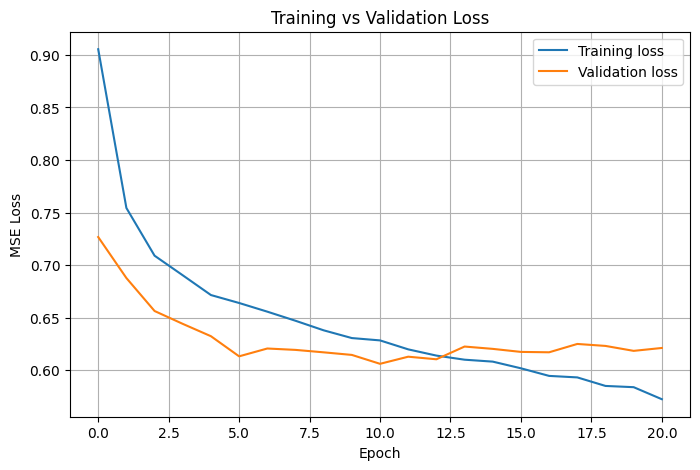

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid()

plt.show()

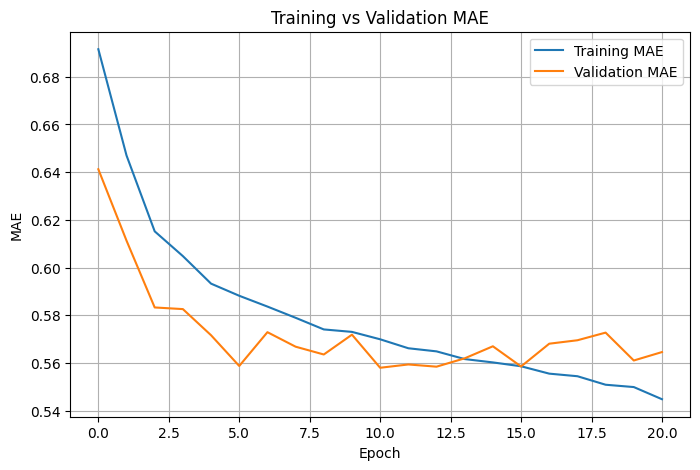

In [29]:
plt.figure(figsize=(8,5))

plt.plot(history.history["mae"], label="Training MAE")
plt.plot(history.history["val_mae"], label="Validation MAE")

plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Training vs Validation MAE")

plt.legend()
plt.grid()

plt.show()

In [30]:
test_loss, test_mae = model.evaluate(
    X_test,
    y_test_scaled
)

print("Test loss:", test_loss)
print("Test MAE:", test_mae)

149/149 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.6409 - mae: 0.5701
Test loss: 0.6408621072769165
Test MAE: 0.5701220035552979


In [31]:
prediction_scaled = model.predict(X_test)

prediction = target_scaler.inverse_transform(prediction_scaled)

149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


In [32]:
for i in range(5):
    print("True:     ", y_test[i])
    print("Predicted:", prediction[i])
    print()

True:      [-4.7320542e-01  4.2953987e+00 -7.0890417e+00  1.0219978e+03]
Predicted: [   1.0927738    2.573888    -7.5987735 1015.0669   ]

True:      [  -1.8619603    4.479793    -6.924948  1021.9978   ]
Predicted: [   1.575675     2.9984958   -7.730919  1023.0719   ]

True:      [   2.2345228    1.8696158   -8.54246   1021.9978   ]
Predicted: [   1.596614     2.0507505   -8.171893  1021.2774   ]

True:      [ 1.3888016e+00  1.1342431e-01 -6.7022667e+00  1.0219978e+03]
Predicted: [   1.0405366    3.717378    -7.4601803 1014.2085   ]

True:      [   3.8511534    2.3501887   -9.376963  1021.9978   ]
Predicted: [   1.7282708    3.6955628   -7.967976  1018.71686  ]



In [33]:
position_error = prediction[:,:3] - y_test[:,:3]


distance_error = np.sqrt(
    position_error[:,0]**2 +
    position_error[:,1]**2 +
    position_error[:,2]**2
)


print(
    "Mean annihilation position error:",
    np.mean(distance_error),
    "mm"
)

Mean annihilation position error: 2.9790893 mm


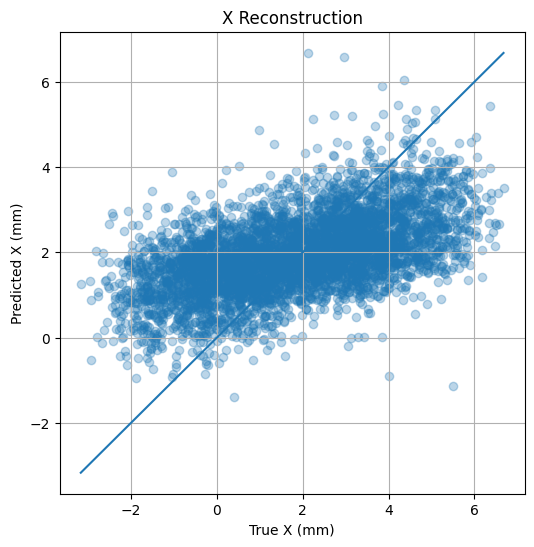

In [34]:
# X
plt.figure(figsize=(6,6))

plt.scatter(
    y_test[:,0],
    prediction[:,0],
    alpha=0.3
)

plt.xlabel("True X (mm)")
plt.ylabel("Predicted X (mm)")
plt.title("X Reconstruction")

plt.plot(
    [y_test[:,0].min(), y_test[:,0].max()],
    [y_test[:,0].min(), y_test[:,0].max()]
)

plt.grid()
plt.show()

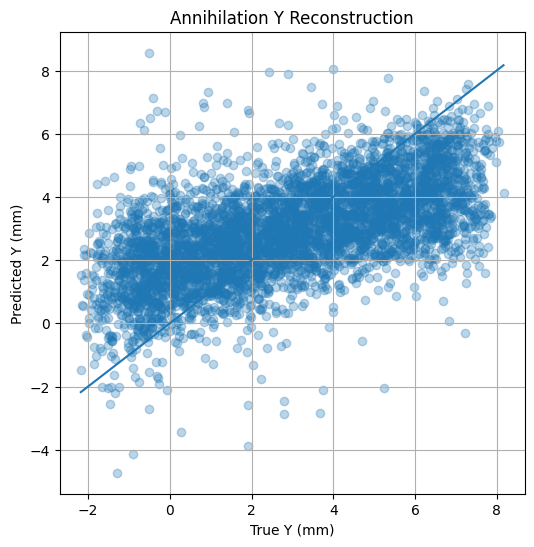

In [35]:
#Y
plt.figure(figsize=(6,6))

plt.scatter(
    y_test[:,1],          # True Y
    prediction[:,1],      # Predicted Y
    alpha=0.3
)

plt.xlabel("True Y (mm)")
plt.ylabel("Predicted Y (mm)")

plt.title("Annihilation Y Reconstruction")


plt.plot(
    [y_test[:,1].min(), y_test[:,1].max()],
    [y_test[:,1].min(), y_test[:,1].max()]
)

plt.grid()
plt.show()

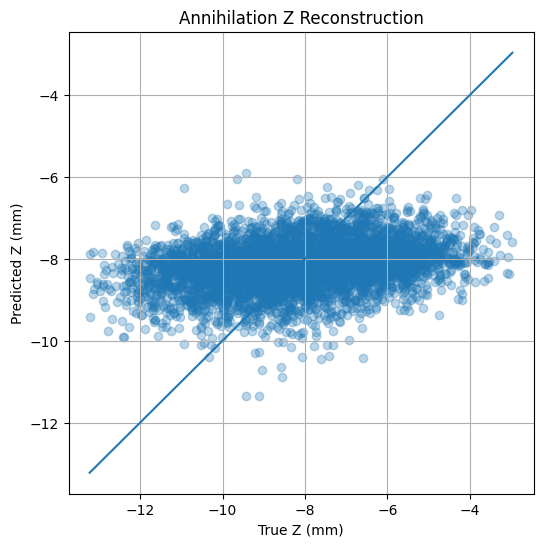

In [36]:
#Z
plt.figure(figsize=(6,6))

plt.scatter(
    y_test[:,2],          # True Z
    prediction[:,2],      # Predicted Z
    alpha=0.3
)

plt.xlabel("True Z (mm)")
plt.ylabel("Predicted Z (mm)")

plt.title("Annihilation Z Reconstruction")


plt.plot(
    [y_test[:,2].min(), y_test[:,2].max()],
    [y_test[:,2].min(), y_test[:,2].max()]
)

plt.grid()
plt.show()

In [ ]:
#energy
plt.figure(figsize=(6,6))

plt.scatter(
    y_test[:,3],          # True energy
    prediction[:,3],      # Predicted energy
    alpha=0.3
)

plt.xlabel("True Energy (keV)")
plt.ylabel("Predicted Energy (keV)")

plt.title("Energy Reconstruction")


plt.plot(
    [y_test[:,3].min(), y_test[:,3].max()],
    [y_test[:,3].min(), y_test[:,3].max()]
)

plt.grid()
plt.show()